# SCRIPT JUST TO CHECK THAT THE CONVERSION FROM VOC TO YOLO OF THE ANNOTATIONS IS WORKING CORRECTLY

In [1]:
import cv2
import os
import matplotlib.pyplot as plt

# Define paths
images_dir = '/home/martina/codi2/3year/synthesisII/bbox_detection/prova_dataset/JPEGImages'
annotations_dir = '/home/martina/codi2/3year/synthesisII/bbox_detection/prova_dataset/Annotations'

# Define class names (must match the order in labels.txt)
classes = ['baby', 'core', 'arm', 'leg', 'hand', 'foot']

def draw_bbox(image, bbox, class_id):
    """
    Draw a bounding box on the image with class-specific colors.
    """
    height, width, _ = image.shape
    x_center, y_center, w, h = bbox

    # Convert YOLO format (normalized) to pixel coordinates
    x1 = int((x_center - w / 2) * width)
    y1 = int((y_center - h / 2) * height)
    x2 = int((x_center + w / 2) * width)
    y2 = int((y_center + h / 2) * height)

    # Define colors for each class
    if classes[class_id] == 'baby':
        color = (0, 0, 0)  # Black
    elif classes[class_id] == 'arm':
        color = (255, 255, 255)  # White
    elif classes[class_id] == 'leg':
        color = (128, 128, 128)  # Gray
    else:
        color = (0, 255, 0)  # Default to green for unknown classes

    # Draw the bounding box
    cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)

    # Add class label
    label = classes[class_id]
    cv2.putText(image, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

def visualize_annotations(image_path, annotation_path):
    """
    Visualize YOLO annotations on an image.
    """
    # Load the image
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error: Unable to load image {image_path}")
        return None

    # Convert BGR to RGB for displaying with matplotlib
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_with_boxes = image_rgb.copy()

    # Load the YOLO annotations
    if not os.path.exists(annotation_path):
        print(f"Warning: {annotation_path} does not exist. Skipping.")
        return None

    with open(annotation_path, 'r') as file:
        lines = file.readlines()

    # Draw each bounding box
    for line in lines:
        class_id, x_center, y_center, w, h = map(float, line.strip().split())
        draw_bbox(image_with_boxes, (x_center, y_center, w, h), int(class_id))

    return image_rgb, image_with_boxes

def plot_images(image_rgb, image_with_boxes):
    """
    Plot the original image and the image with bounding boxes side by side.
    """
    plt.figure(figsize=(12, 6))

    # Plot original image
    plt.subplot(1, 2, 1)
    plt.imshow(image_rgb)
    plt.title("Original Image")
    plt.axis('off')

    # Plot image with bounding boxes
    plt.subplot(1, 2, 2)
    plt.imshow(image_with_boxes)
    plt.title("Image with Bounding Boxes")
    plt.axis('off')

    plt.show()

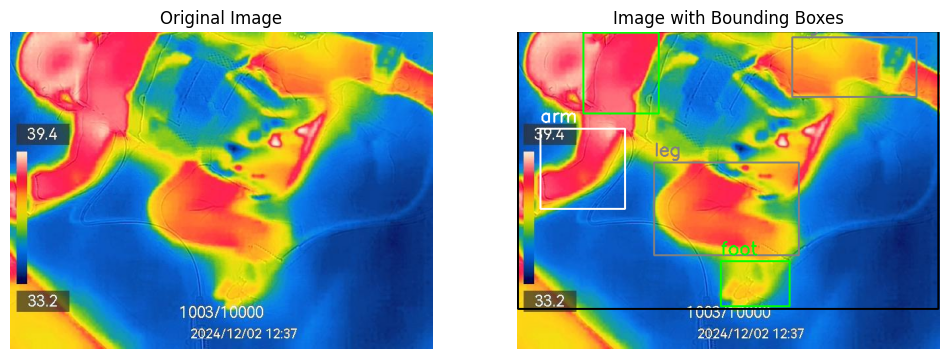

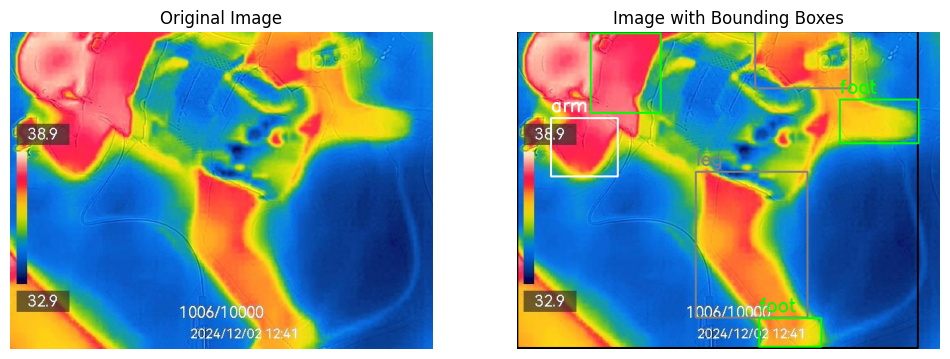

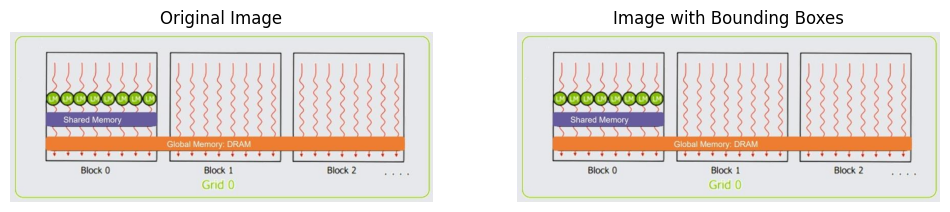

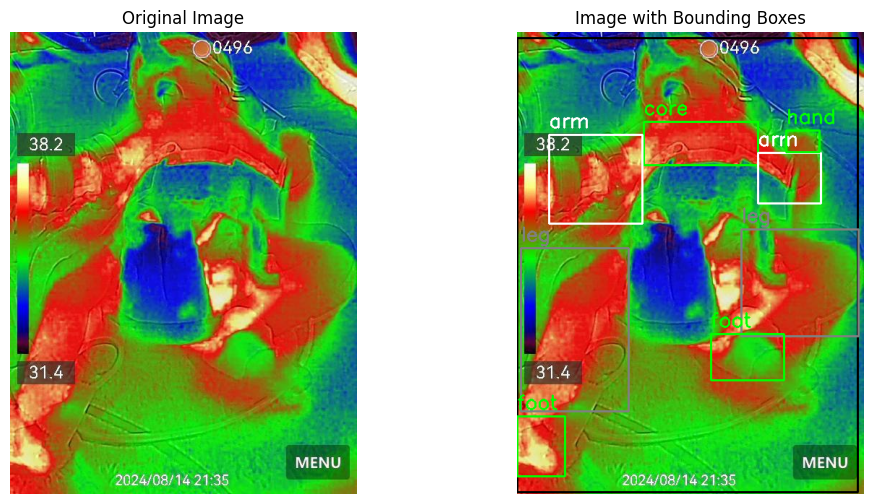

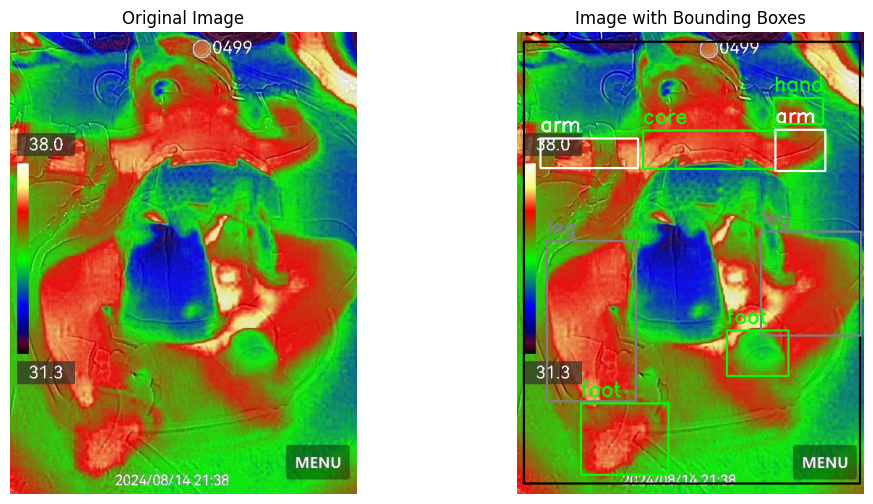

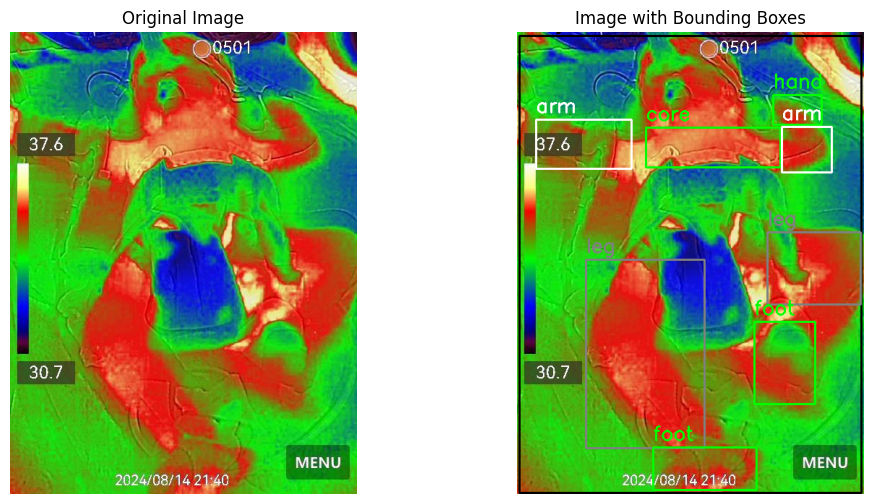

In [2]:
# Get all image paths
image_paths = [os.path.join(images_dir, f) for f in os.listdir(images_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]

# Visualize annotations for each image
for image_path in image_paths:
    # Get the corresponding annotation file
    basename = os.path.basename(image_path)
    basename_no_ext = os.path.splitext(basename)[0]
    annotation_path = os.path.join(annotations_dir, basename_no_ext + '.txt')

    # Visualize the annotations
    result = visualize_annotations(image_path, annotation_path)
    if result is not None:
        image_rgb, image_with_boxes = result
        plot_images(image_rgb, image_with_boxes)